# Information-Theory Measures with Gaussianization Flows

!!! note "Requirements"
    Beyond `gauss_flows`, this notebook uses the
    [`rbig`](https://github.com/jejjohnson/rbig) package and `pandas`:
    `pip install rbig pandas`.

This notebook reproduces the
[RBIG information-theory notebook](https://jejjohnson.github.io/rbig/notebooks/06_information_theory/)
for `gauss_flows`. We estimate four information-theoretic quantities of a
correlated multivariate Gaussian:

* **Entropy** $H(X)$
* **Total correlation** $\mathrm{TC}(X)$
* **Mutual information** $I(X; Y)$
* **KL divergence** $\mathrm{KL}(P \,\|\, Q)$

Each quantity is computed **three ways**:

1. **Analytical** — the closed form for a Gaussian (ground truth).
2. **Change-of-variables** — using the exact flow log-density
   $\log p(x) = \log p_Z(f(x)) + \log|\det J_f(x)|$.
3. **RBIG-way** — accumulating the total correlation removed by the
   Gaussianization (no Jacobian needed).

As icing on the cake we run **three models**:

* **RBIG** — `AnnealedRBIG` from the [`rbig`](https://github.com/jejjohnson/rbig) package.
* **GF-Diagonal** — a `gauss_flows` diagonal Gaussianization flow (`fit_rbig`).
* **GF-Coupling** — a `gauss_flows` mixture-CDF coupling flow (`fit_rbig_coupling`).

Both `gauss_flows` models are **RBIG warm-started** (see the
[RBIG warm-start notebook](03_rbig_warmstart.ipynb)) and then briefly
fine-tuned, so they converge quickly to an accurate density.

In [1]:
from __future__ import annotations

import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from flowjax.train import fit_to_data

from gauss_flows import fit_rbig, fit_rbig_coupling
from gauss_flows._src.info_theory import (
    entropy,
    entropy_reduction,
    gaussian_entropy,
    gaussian_kl_divergence,
    gaussian_mutual_information,
    gaussian_total_correlation,
    kl_divergence,
    kl_divergence_reduction,
    mutual_information,
    total_correlation,
    total_correlation_reduction,
)

from rbig import (
    AnnealedRBIG,
    estimate_entropy,
    estimate_kld,
    estimate_mi,
    estimate_tc,
    kl_divergence_rbig,
    mutual_information_rbig,
    total_correlation_rbig,
)

/home/user/gauss_flows/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Synthetic data

We build a 4-dimensional Gaussian split into two 2-D blocks $X$ and $Y$ with
cross-correlations $\rho = 0.8$ and $\rho = 0.5$, exactly as in the RBIG
notebook. For the KL divergence we use a mean-shifted copy of $X$.

In [2]:
seed = 42
rng = np.random.RandomState(seed)
n_samples = 2_000
d = 2  # dimensionality per block

# Joint covariance for [X, Y] with cross-correlations.
C_full = np.eye(2 * d)
C_full[0, d] = C_full[d, 0] = 0.8  # x0 <-> y0
C_full[1, d + 1] = C_full[d + 1, 1] = 0.5  # x1 <-> y1

joint = rng.multivariate_normal(np.zeros(2 * d), C_full, size=n_samples)
X = joint[:, :d].astype(np.float32)
Y = joint[:, d:].astype(np.float32)
XY = joint.astype(np.float32)

CX = C_full[:d, :d]
CY = C_full[d:, d:]

# Mean-shifted distribution for the KL divergence.
mu_shift = np.array([0.5, 0.0])
X_shifted = rng.multivariate_normal(mu_shift, CX, size=n_samples).astype(np.float32)

Xj, Yj, XYj = jnp.asarray(X), jnp.asarray(Y), jnp.asarray(XY)
Xs_j = jnp.asarray(X_shifted)

print(f"X: {X.shape}, Y: {Y.shape}, XY: {XY.shape}")

X: (2000, 2), Y: (2000, 2), XY: (2000, 4)


## 2. Analytical ground truth

Closed-form Gaussian expressions via `gauss_flows`'s analytical helpers.

In [3]:
H_X_true = float(gaussian_entropy(CX))
H_Y_true = float(gaussian_entropy(CY))
H_XY_true = float(gaussian_entropy(C_full))
TC_X_true = float(gaussian_total_correlation(CX))
TC_XY_true = float(gaussian_total_correlation(C_full))
MI_true = float(gaussian_mutual_information(C_full, dim_x=d))
KL_true = float(
    gaussian_kl_divergence(mu_shift, CX, np.zeros(d), CX)
)  # KL(N(mu, CX) || N(0, CX))

print(f"H(X)     = {H_X_true:+.4f}")
print(f"H(X,Y)   = {H_XY_true:+.4f}")
print(f"TC(X)    = {TC_X_true:+.4f}")
print(f"TC(X,Y)  = {TC_XY_true:+.4f}")
print(f"MI(X;Y)  = {MI_true:+.4f}")
print(f"KL       = {KL_true:+.4f}")

H(X)     = +2.8379
H(X,Y)   = +5.0211
TC(X)    = +0.0000
TC(X,Y)  = +0.6547
MI(X;Y)  = +0.6547
KL       = +0.1250


## 3. Fit the three models

### 3a. RBIG (`rbig` package)

In [4]:
rbig_kw = dict(n_layers=20, rotation="pca", patience=10, random_state=seed)

rbig_X = AnnealedRBIG(**rbig_kw).fit(X)
rbig_Y = AnnealedRBIG(**rbig_kw).fit(Y)
rbig_XY = AnnealedRBIG(**rbig_kw).fit(XY)
rbig_ref = AnnealedRBIG(**rbig_kw).fit(X)  # reference Q = N(0, CX) for the KL

### 3b. `gauss_flows` models — RBIG warm-start + short fine-tune

We warm-start each flow with RBIG (gradient-free) and then run a few epochs of
`flowjax.train.fit_to_data`. The warm-start means the flow is already close to
the target, so only light fine-tuning is needed.

In [5]:
def fit_diagonal(data, key, n_layers=8, n_components=8, max_epochs=80):
    """RBIG warm-started diagonal Gaussianization flow + short fine-tune."""
    flow = fit_rbig(jnp.asarray(data), n_layers=n_layers, n_components=n_components)
    flow, _ = fit_to_data(
        key,
        flow,
        jnp.asarray(data),
        learning_rate=5e-3,
        max_epochs=max_epochs,
        max_patience=max_epochs,
        batch_size=256,
        val_prop=0.1,
        show_progress=False,
    )
    return flow


def fit_coupling(data, key, n_layers=4, n_components=8, max_epochs=80):
    """RBIG warm-started mixture-CDF coupling flow + short fine-tune."""
    k_init, k_train = jr.split(key)
    flow = fit_rbig_coupling(
        jnp.asarray(data),
        k_init,
        n_layers=n_layers,
        n_components=n_components,
        nn_width=64,
        nn_depth=2,
    )
    flow, _ = fit_to_data(
        k_train,
        flow,
        jnp.asarray(data),
        learning_rate=3e-3,
        max_epochs=max_epochs,
        max_patience=max_epochs,
        batch_size=256,
        val_prop=0.1,
        show_progress=False,
    )
    return flow


keys = jr.split(jr.key(0), 8)
diag_X = fit_diagonal(X, keys[0])
diag_Y = fit_diagonal(Y, keys[1])
diag_XY = fit_diagonal(XY, keys[2])
diag_shift = fit_diagonal(X_shifted, keys[3])

cpl_X = fit_coupling(X, keys[4])
cpl_Y = fit_coupling(Y, keys[5])
cpl_XY = fit_coupling(XY, keys[6])
cpl_shift = fit_coupling(X_shifted, keys[7])

# Sanity check: mean log-likelihood per model.
for name, flow in [("GF-Diagonal", diag_XY), ("GF-Coupling", cpl_XY)]:
    ll = float(jnp.mean(jax.vmap(flow.log_prob)(XYj)))
    print(f"{name:12s}  mean log-likelihood on XY: {ll:+.4f} nats")

GF-Diagonal   mean log-likelihood on XY: -5.0899 nats


GF-Coupling   mean log-likelihood on XY: -5.0065 nats


## 4. Change-of-variables estimates

Here every estimate uses an exact log-density. For the flows this is
`flow.log_prob` (Monte-Carlo over flow samples); for RBIG it is
`AnnealedRBIG.score_samples` (the flow change-of-variables formula with the
per-layer log-determinant Jacobian).

In [6]:
mc = jr.split(jr.key(1), 24)
n_mc = 5000

# --- GF-Diagonal ---
H_X_diag = float(entropy(diag_X, n_mc, key=mc[0]))
H_XY_diag = float(entropy(diag_XY, n_mc, key=mc[1]))
TC_X_diag = float(total_correlation(diag_X, n_mc, key=mc[2]))
TC_XY_diag = float(total_correlation(diag_XY, n_mc, key=mc[3]))
MI_diag = float(mutual_information(diag_XY, diag_X, diag_Y, n_mc, key=mc[4]))
KL_diag = float(kl_divergence(diag_shift, diag_X, n_mc, key=mc[5]))

# --- GF-Coupling ---
H_X_cpl = float(entropy(cpl_X, n_mc, key=mc[6]))
H_XY_cpl = float(entropy(cpl_XY, n_mc, key=mc[7]))
TC_X_cpl = float(total_correlation(cpl_X, n_mc, key=mc[8]))
TC_XY_cpl = float(total_correlation(cpl_XY, n_mc, key=mc[9]))
MI_cpl = float(mutual_information(cpl_XY, cpl_X, cpl_Y, n_mc, key=mc[10]))
KL_cpl = float(kl_divergence(cpl_shift, cpl_X, n_mc, key=mc[11]))

# --- RBIG ---
H_X_rbig_cov = float(rbig_X.entropy())
H_XY_rbig_cov = float(rbig_XY.entropy())
TC_X_rbig_cov = float(total_correlation_rbig(X))
TC_XY_rbig_cov = float(total_correlation_rbig(XY))
MI_rbig_cov = float(mutual_information_rbig(rbig_X, rbig_Y, rbig_XY))
KL_rbig_cov = float(kl_divergence_rbig(rbig_ref, X_shifted))

## 5. RBIG-way estimates

These accumulate the total correlation removed by the Gaussianization. For the
flows we use `total_correlation_reduction` / `entropy_reduction` /
`kl_divergence_reduction`; for RBIG we use the `estimate_*` helpers.

In [7]:
def mi_reduction(flow_x, flow_y, x, y, fit_joint):
    """RBIG-way MI = total correlation of [G_X(x), G_Y(y)]."""
    zx = jax.vmap(flow_x.bijection.inverse)(jnp.asarray(x))
    zy = jax.vmap(flow_y.bijection.inverse)(jnp.asarray(y))
    z = jnp.concatenate([zx, zy], axis=-1)
    flow_z = fit_joint(np.asarray(z))
    return float(total_correlation_reduction(flow_z, z))


# --- GF-Diagonal ---
H_X_diag_r = float(entropy_reduction(diag_X, Xj))
H_XY_diag_r = float(entropy_reduction(diag_XY, XYj))
TC_X_diag_r = float(total_correlation_reduction(diag_X, Xj))
TC_XY_diag_r = float(total_correlation_reduction(diag_XY, XYj))
MI_diag_r = mi_reduction(diag_X, diag_Y, X, Y, lambda z: fit_diagonal(z, jr.key(100)))
KL_diag_r = float(kl_divergence_reduction(diag_X, Xs_j))

# --- GF-Coupling ---
H_X_cpl_r = float(entropy_reduction(cpl_X, Xj))
H_XY_cpl_r = float(entropy_reduction(cpl_XY, XYj))
TC_X_cpl_r = float(total_correlation_reduction(cpl_X, Xj))
TC_XY_cpl_r = float(total_correlation_reduction(cpl_XY, XYj))
MI_cpl_r = mi_reduction(cpl_X, cpl_Y, X, Y, lambda z: fit_coupling(z, jr.key(101)))
KL_cpl_r = float(kl_divergence_reduction(cpl_X, Xs_j))

# --- RBIG ---
H_X_rbig_r = float(estimate_entropy(X, **rbig_kw))
H_XY_rbig_r = float(estimate_entropy(XY, **rbig_kw))
TC_X_rbig_r = float(estimate_tc(X, **rbig_kw))
TC_XY_rbig_r = float(estimate_tc(XY, **rbig_kw))
MI_rbig_r = float(estimate_mi(X, Y, **rbig_kw))
KL_rbig_r = float(estimate_kld(X_shifted, X, **rbig_kw))

## 6. Comparison

Columns are the three models; rows group the measures by estimation method.

In [8]:
rows = [
    ("H(X)", "change-of-vars", H_X_true, H_X_rbig_cov, H_X_diag, H_X_cpl),
    ("H(X)", "RBIG-way", H_X_true, H_X_rbig_r, H_X_diag_r, H_X_cpl_r),
    ("H(X,Y)", "change-of-vars", H_XY_true, H_XY_rbig_cov, H_XY_diag, H_XY_cpl),
    ("H(X,Y)", "RBIG-way", H_XY_true, H_XY_rbig_r, H_XY_diag_r, H_XY_cpl_r),
    ("TC(X)", "change-of-vars", TC_X_true, TC_X_rbig_cov, TC_X_diag, TC_X_cpl),
    ("TC(X)", "RBIG-way", TC_X_true, TC_X_rbig_r, TC_X_diag_r, TC_X_cpl_r),
    ("TC(X,Y)", "change-of-vars", TC_XY_true, TC_XY_rbig_cov, TC_XY_diag, TC_XY_cpl),
    ("TC(X,Y)", "RBIG-way", TC_XY_true, TC_XY_rbig_r, TC_XY_diag_r, TC_XY_cpl_r),
    ("MI(X;Y)", "change-of-vars", MI_true, MI_rbig_cov, MI_diag, MI_cpl),
    ("MI(X;Y)", "RBIG-way", MI_true, MI_rbig_r, MI_diag_r, MI_cpl_r),
    ("KL(P||Q)", "change-of-vars", KL_true, KL_rbig_cov, KL_diag, KL_cpl),
    ("KL(P||Q)", "RBIG-way", KL_true, KL_rbig_r, KL_diag_r, KL_cpl_r),
]
table = pd.DataFrame(
    rows,
    columns=["measure", "method", "Analytical", "RBIG", "GF-Diagonal", "GF-Coupling"],
)
table = table.set_index(["measure", "method"])
table.round(4)

Analytical    RBIG  GF-Diagonal  GF-Coupling
measure  method                                                      
H(X)     change-of-vars      2.8379  2.8462       2.7806       2.8297
         RBIG-way            2.8379  2.8454       2.8243       2.8242
H(X,Y)   change-of-vars      5.0211  4.8815       4.9168       5.0219
         RBIG-way            5.0211  5.0380       5.0013       4.9952
TC(X)    change-of-vars      0.0000 -0.0048       0.0475       0.0446
         RBIG-way            0.0000 -0.0051      -0.0021      -0.0020
TC(X,Y)  change-of-vars      0.6547  0.6218       0.8368       0.7157
         RBIG-way            0.6547  0.6325       0.6307       0.6368
MI(X;Y)  change-of-vars      0.6547  0.7990       0.6864       0.6806
         RBIG-way            0.6547  0.6427       0.6390       0.6227
KL(P||Q) change-of-vars      0.1250  0.7051       0.3594       0.3056
         RBIG-way            0.1250  0.1415       0.1408       0.1358

## 7. Visual comparison

Absolute error of each estimator against the analytical ground truth.

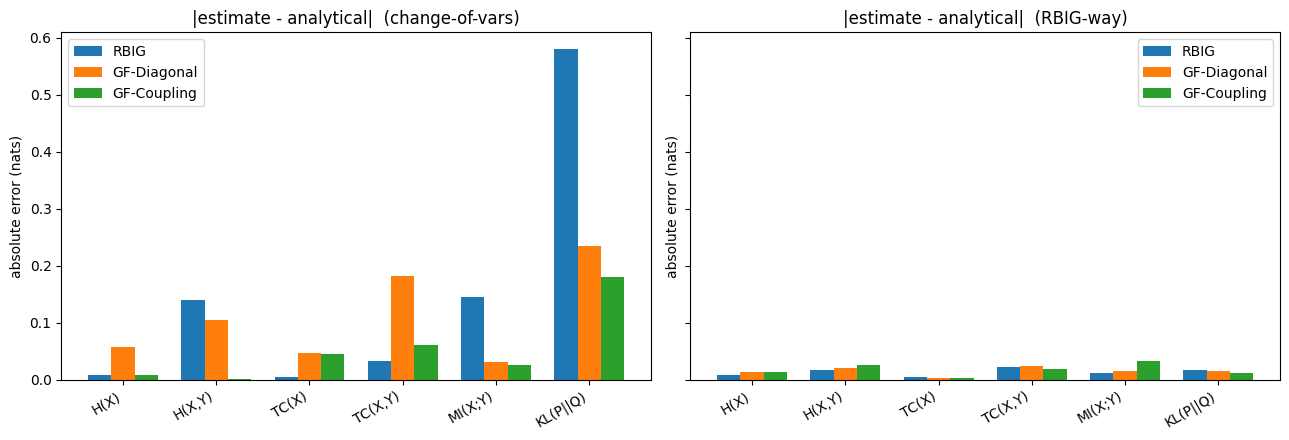

In [9]:
measures = ["H(X)", "H(X,Y)", "TC(X)", "TC(X,Y)", "MI(X;Y)", "KL(P||Q)"]
models = ["RBIG", "GF-Diagonal", "GF-Coupling"]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, method in zip(axes, ["change-of-vars", "RBIG-way"]):
    sub = table.xs(method, level="method")
    err = (sub[models].sub(sub["Analytical"], axis=0)).abs()
    err = err.reindex(measures)
    x = np.arange(len(measures))
    w = 0.25
    for i, m in enumerate(models):
        ax.bar(x + (i - 1) * w, err[m].values, width=w, label=m)
    ax.set_xticks(x)
    ax.set_xticklabels(measures, rotation=30, ha="right")
    ax.set_title(f"|estimate - analytical|  ({method})")
    ax.set_ylabel("absolute error (nats)")
    ax.legend()
fig.tight_layout()
plt.show()

## Summary

All three models recover the analytical Gaussian quantities closely. The
**change-of-variables** route leans on each model's exact log-density, while
the **RBIG-way** route only needs the total correlation removed by
Gaussianization. The RBIG warm-start lets the `gauss_flows` diagonal and
coupling flows reach accurate densities after only a short fine-tune.